<a href="https://colab.research.google.com/github/sevdeaslanturkiyeli/AI_Development_Bootcamp/blob/main/03_missing_data_removal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Missing Value Problem

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno #missing data visualization library

In [3]:
#data link: https://gist.github.com/inoccu/139294a0476751fbfd1cde4110edbbab

df = pd.read_csv("housing.csv")
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [4]:
df.columns.tolist()

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'MEDV']

In [6]:
# general summary of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
df.describe() #Basic statistical analysis for numerical columns


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [8]:
# missing value check
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [10]:
missing_percent = df.isnull().mean() * 100 #missing percentage in each column
missing_percent

,0
CRIM,0.0
ZN,0.0
INDUS,0.0
CHAS,0.0
NOX,0.0
RM,0.0
AGE,0.0
DIS,0.0
RAD,0.0
TAX,0.0


In [12]:
# Let's simulate the missing values.
np.random.seed(42)

for col in ["AGE","DIS"]:
  df.loc[df.sample(frac=0.1).index,col] = np.nan #null value

df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,51
DIS,51
RAD,0
TAX,0


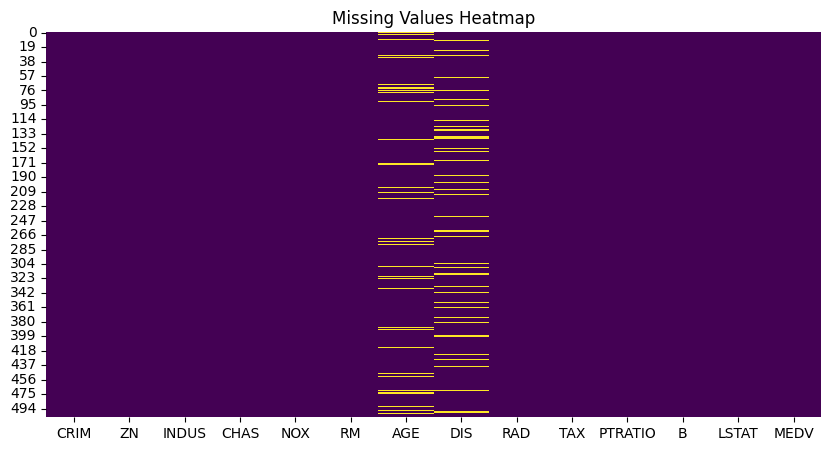

In [13]:
# visualization of missing values

plt.figure(figsize = (10,5))
sns.heatmap(df.isnull(),cbar = False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

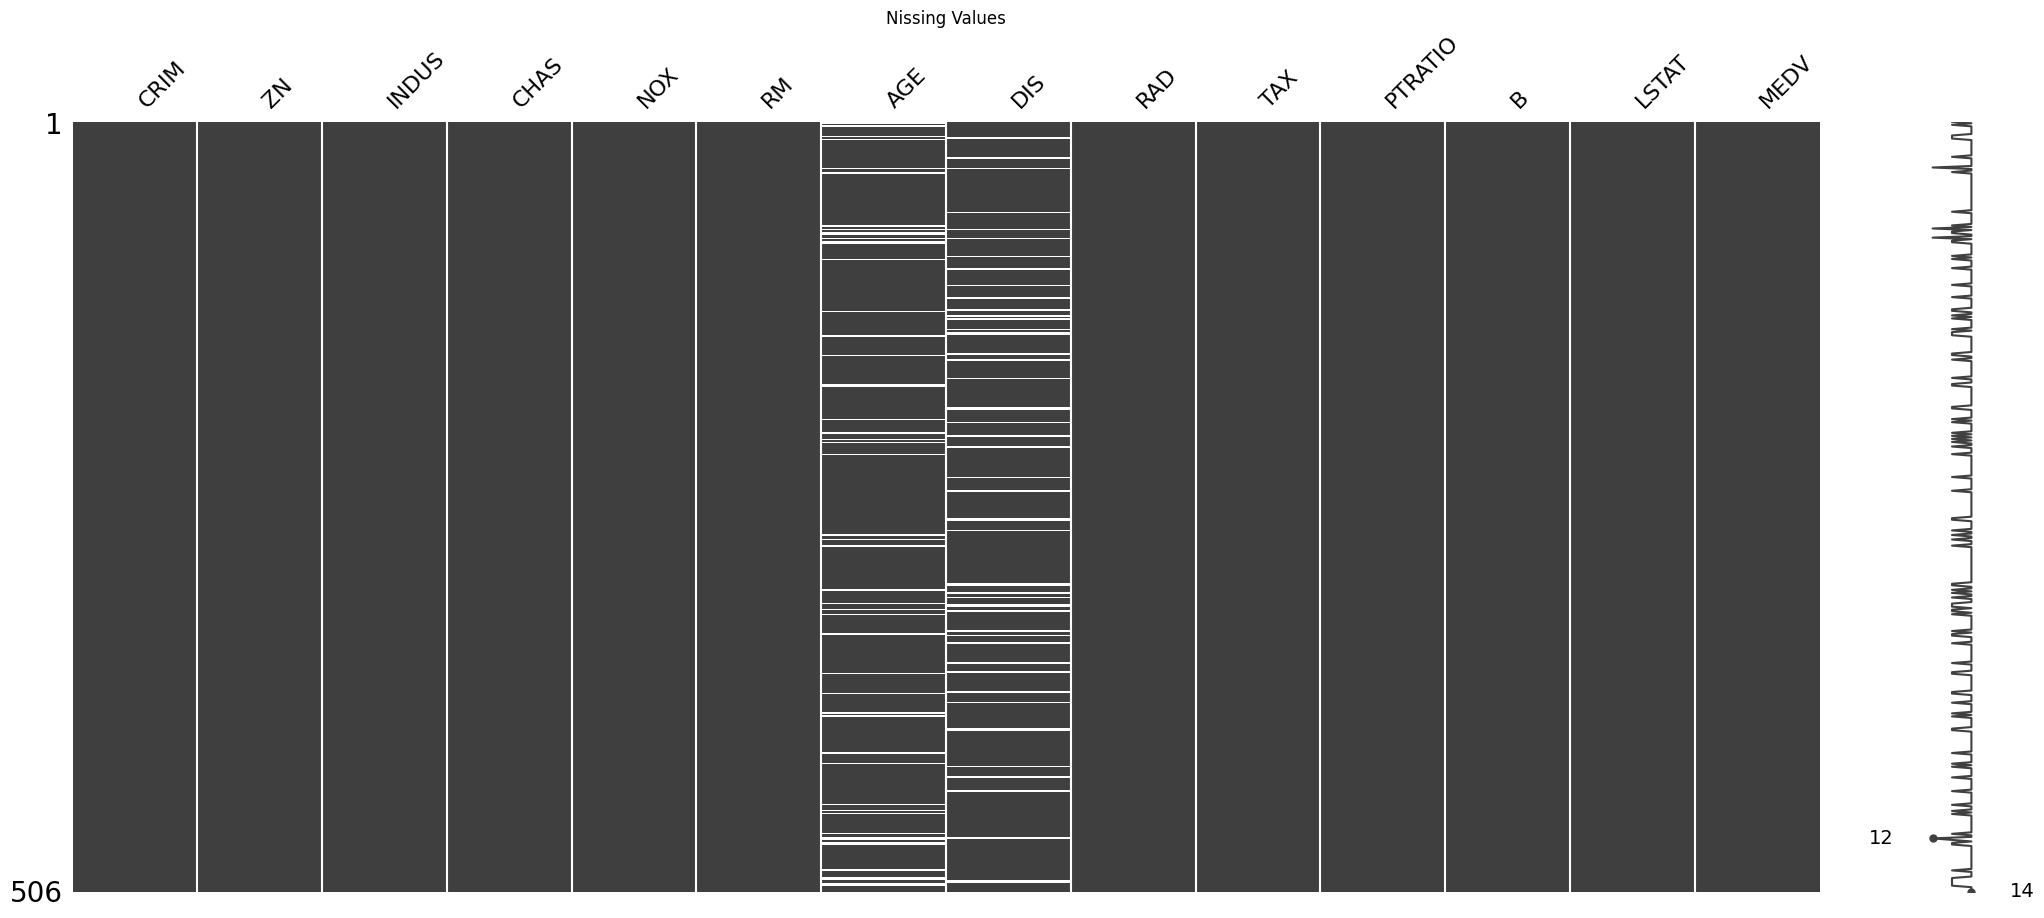

In [14]:
# alternative - missingno library

msno.matrix(df)
plt.title("Nissing Values")
plt.show()

In [16]:
#shortage rate analysis table

missing_report = pd.DataFrame({
    "missing_number": df.isnull().sum(),
    "missing_rate": round(df.isnull().mean()*100,1)
})

print(missing_report.sort_values(by="missing_rate", ascending = False))

         missing_number  missing_rate
DIS                  51          10.1
AGE                  51          10.1
INDUS                 0           0.0
CHAS                  0           0.0
CRIM                  0           0.0
ZN                    0           0.0
RM                    0           0.0
NOX                   0           0.0
RAD                   0           0.0
TAX                   0           0.0
PTRATIO               0           0.0
B                     0           0.0
LSTAT                 0           0.0
MEDV                  0           0.0


##Fill in missing data


In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print(df.isnull().sum())

CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE        51
DIS        51
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV        0
dtype: int64


In [23]:
# Fill in with mean value

df_mean = df.copy()

mean_value = df_mean["AGE"].mean()

df_mean["AGE"].fillna(mean_value, inplace = True)

print(f"The age column was populated with the average {mean_value:2f} value.")

The age column was populated with the average 68.252747 value.


/tmp/ipykernel_1487/2953874990.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean["AGE"].fillna(mean_value, inplace = True)


In [25]:
df_mean.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,51
RAD,0
TAX,0


In [26]:
# Fill in with median value

df_median = df.copy()

median_value = df_median["DIS"].median()
df_median["DIS"].fillna(median_value, inplace = True)

print(f"DIS column was populated with the median {median_value:2f} value.")

DIS column was populated with the median 3.215700 value.


/tmp/ipykernel_1487/3393052267.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_median["DIS"].fillna(median_value, inplace = True)


In [27]:
df_median.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,51
DIS,0
RAD,0
TAX,0


In [28]:
# Fill in with mod value

np.random.seed(42)

for col in ["CHAS"]:
  df.loc[df.sample(frac=0.1).index,col] = np.nan #null value

df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,51
NOX,0
RM,0
AGE,51
DIS,51
RAD,0
TAX,0


In [29]:
df_mode = df.copy()

mode_value = df_mode["CHAS"].mode()[0]
df_mode["CHAS"].fillna(mode_value, inplace = True)

print(f"CHAS column was populated with the mode {mode_value:2f} value.")


CHAS column was populated with the mode 0.000000 value.


/tmp/ipykernel_1487/2999641341.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mode["CHAS"].fillna(mode_value, inplace = True)


In [30]:
df_mode.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,51
DIS,51
RAD,0
TAX,0


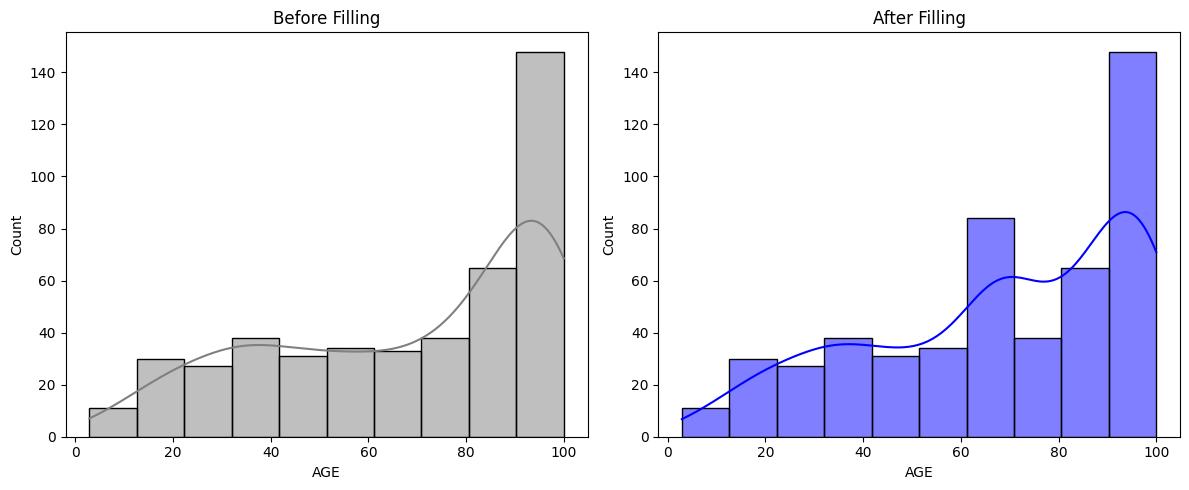

In [35]:
# Comparison before and after filling

plt.figure(figsize =(12,5))

plt.subplot(1,2,1)
sns.histplot(df["AGE"],color="gray", kde = True)
plt.title("Before Filling")

plt.subplot(1,2,2)
sns.histplot(df_mean["AGE"],color="blue", kde = True)
plt.title("After Filling")
plt.tight_layout()
plt.show()

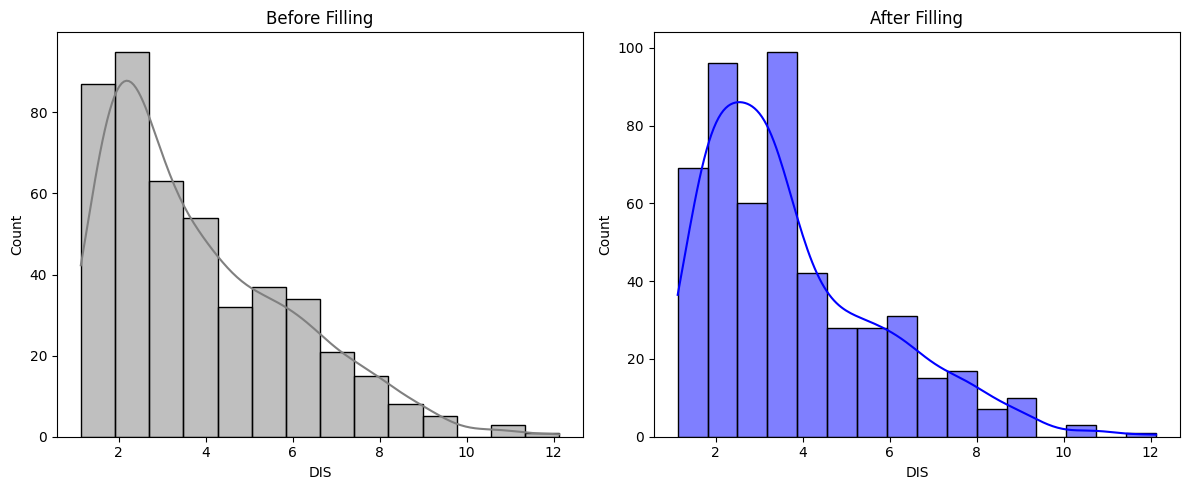

In [36]:
plt.figure(figsize =(12,5))

plt.subplot(1,2,1)
sns.histplot(df["DIS"],color="gray", kde = True)
plt.title("Before Filling")

plt.subplot(1,2,2)
sns.histplot(df_median["DIS"],color="blue", kde = True)
plt.title("After Filling")
plt.tight_layout()
plt.show()

## Advanced Methods

In [37]:
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [39]:
df = pd.read_csv("housing.csv")

np.random.seed(42)
for col in ["AGE","DIS","RM"]:
  df.loc[df.sample(frac = 0.1).index, col] = np.nan

print(df.isnull().sum())

CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM         51
AGE        51
DIS        51
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV        0
dtype: int64


In [40]:
# Fill in with KNN

df_knn = df.copy()

imputer = KNNImputer(n_neighbors=3)
df_knn_imputed = imputer.fit_transform(df_knn)

df_knn = pd.DataFrame(df_knn_imputed, columns = df.columns)

df_knn.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [45]:
# Fill in with Regression

df_reg = df.copy()

#Separate the complete lines as "train" and the missing lines as "predict".
train_data = df_reg[df_reg["AGE"].notnull()]
predict_data = df_reg[df_reg["AGE"].isnull()]

train_data = train_data.fillna(train_data.mean())
predict_data = predict_data.fillna(predict_data.mean())


X_train = train_data.drop(columns = ["AGE"])
y_train = train_data["AGE"]
X_pred = predict_data.drop(columns = ["AGE"])

#create regression model

model = LinearRegression()
model.fit(X_train, y_train)

#predict missing values

predicted_values = model.predict(X_pred)

#fill in missing values

df_reg.loc[df_reg["AGE"].isnull(), "AGE"] = predicted_values

df_reg["AGE"].isnull().sum()


np.int64(0)